# Car Plate Digit Recognition — `best.pt` Evaluation Notebook

**Pipeline:**
```
Input Image → Preprocessing → YOLO Detection (best.pt) → Crop ROI → EasyOCR Recognition → Post-processing → Output
```

This notebook lets you:
1. Load your custom-trained `best.pt` model
2. Run it on uploaded images (with or without labels)
3. Visualize detections + recognized digits
4. Compute metrics (CER, Digit Accuracy, Sequence Accuracy) if labels are provided
5. Register the model as a new pipeline in your benchmark system

## 0. Install / check dependencies

In [2]:
import importlib, subprocess, sys

required = {
    'ultralytics': 'ultralytics',
    'easyocr':     'easyocr',
    'cv2':         'opencv-python',
    'matplotlib':  'matplotlib',
    'pandas':      'pandas',
    'jiwer':       'jiwer',
}

for module, pkg in required.items():
    if importlib.util.find_spec(module) is None:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All dependencies ready ✓')

All dependencies ready ✓


## 1. Configuration — edit this cell

In [3]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────
MODEL_PATH   = 'best.pt'          # path to your trained weights
IMAGES_DIR   = 'datasets/dataset/images'      # folder with test images 
LABELS_FILE  = 'datasets/dataset/labels.csv'  # CSV with image_name,label columns

# ── Detection settings ───────────────────────────────────────────────────────
CONF_THRESHOLD = 0.25             # lower = more detections, higher = more precise
IOU_THRESHOLD  = 0.45
IMGSZ          = 640

# ── OCR settings ─────────────────────────────────────────────────────────────
USE_GPU        = False            # set True if you have CUDA
CROP_PADDING   = 6               # pixels to expand each detected box

# ── Output ───────────────────────────────────────────────────────────────────
SAVE_ANNOTATED = True             # save annotated images to annotated/ folder
MAX_DISPLAY    = 12               # max images to show in notebook

# Validate
assert Path(MODEL_PATH).exists(), f'Model not found: {MODEL_PATH}'
assert Path(IMAGES_DIR).exists(), f'Images folder not found: {IMAGES_DIR}'
print(f'Model : {MODEL_PATH}')
print(f'Images: {IMAGES_DIR}')
print(f'Labels: {LABELS_FILE if Path(LABELS_FILE).exists() else "(none — metrics disabled)"}')

Model : best.pt
Images: datasets/dataset/images
Labels: (none — metrics disabled)


## 2. Load model + OCR engine

In [4]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO

print('Loading YOLO model...')
model = YOLO(MODEL_PATH)
print(f'  Classes : {model.names}')
print(f'  Task    : {model.task}')

print('Loading EasyOCR...')
reader = easyocr.Reader(['en'], gpu=USE_GPU, verbose=False)
print('Models loaded ✓')

Loading YOLO model...
  Classes : {0: 'item'}
  Task    : detect
Loading EasyOCR...
Models loaded ✓


## 3. Preprocessing + helper functions

In [5]:
def preprocess_image(image: np.ndarray) -> np.ndarray:
    """Resize to detection size while keeping aspect ratio."""
    h, w = image.shape[:2]
    scale = IMGSZ / max(h, w)
    if scale < 1.0:  # only downscale, never upscale for detection
        image = cv2.resize(image, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_LINEAR)
    return image


def preprocess_crop_for_ocr(crop: np.ndarray) -> np.ndarray:
    """Adaptive thresholding pipeline — works on real plate photos."""
    if len(crop.shape) == 3:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = crop.copy()

    # Ensure minimum height for OCR
    h, w = gray.shape
    if h < 64:
        gray = cv2.resize(gray, (int(w * 64 / h), 64), interpolation=cv2.INTER_CUBIC)

    # Upscale x2
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # CLAHE for local contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Mild denoise
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Adaptive threshold — handles uneven backgrounds
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        15, 10
    )

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return thresh


def recognize_crop(crop: np.ndarray) -> tuple[str, float]:
    """Run EasyOCR on a crop, return (digits_only, confidence)."""
    prepared = preprocess_crop_for_ocr(crop)

    # Try multiple configs — keep first non-empty result
    attempts = [
        dict(allowlist='0123456789', paragraph=False, detail=1,
             min_size=5, contrast_ths=0.1, adjust_contrast=0.5),
        dict(allowlist='0123456789', paragraph=True,  detail=1,
             min_size=5, contrast_ths=0.1, adjust_contrast=0.5),
        dict(allowlist='0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ',
             paragraph=False, detail=1),  # fallback: allow letters too
    ]

    for kwargs in attempts:
        try:
            results = reader.readtext(prepared, **kwargs)
        except Exception:
            results = []
        if results:
            text = ''.join(r[1] for r in results if len(r) >= 2)
            digits = ''.join(c for c in text if c.isdigit())
            conf   = float(np.mean([r[2] for r in results if len(r) >= 3]))
            if digits:
                return digits, conf

    return '', 0.0


def extract_digit_text(text: str) -> str:
    return ''.join(c for c in text if c.isdigit())


print('Helper functions defined ✓')

Helper functions defined ✓


## 4. Load images + labels

In [6]:
import pandas as pd

# Load only first 50 images
all_image_paths = sorted(Path(IMAGES_DIR).glob('*'))
image_paths = [p for p in all_image_paths[:50]  # Take only first 50
               if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.webp')]

print(f'Found {len(image_paths)} images (showing first 50 of {len(all_image_paths)} total) in {IMAGES_DIR}/')

# Load labels if provided
label_dict = {}
if LABELS_FILE and Path(LABELS_FILE).exists():
    df_labels = pd.read_csv(LABELS_FILE)
    # Support columns: image_name,label  OR  filename,label
    name_col  = 'image_name' if 'image_name' in df_labels.columns else df_labels.columns[0]
    label_col = 'label'      if 'label'      in df_labels.columns else df_labels.columns[1]
    label_dict = dict(zip(df_labels[name_col].astype(str), df_labels[label_col].astype(str)))
    print(f'Loaded {len(label_dict)} labels from {LABELS_FILE}')
else:
    print('No labels file — running inference-only mode')

if not image_paths:
    raise FileNotFoundError(f'No images found in {IMAGES_DIR}/')

Found 50 images (showing first 50 of 3463 total) in datasets/dataset/images/
No labels file — running inference-only mode


## 5. Run full pipeline on all images

In [7]:
import time
from dataclasses import dataclass, field
from typing import List

@dataclass
class SampleResult:
    image_name:   str
    ground_truth: str
    prediction:   str
    num_boxes:    int
    latency_ms:   float
    annotated:    np.ndarray = field(repr=False)
    boxes:        list       = field(default_factory=list)


results: List[SampleResult] = []
out_dir = Path('annotated')
if SAVE_ANNOTATED:
    out_dir.mkdir(exist_ok=True)

for i, img_path in enumerate(image_paths):
    t0 = time.time()

    # ── Load & preprocess ────────────────────────────────────────────────────
    image = cv2.imread(str(img_path))
    if image is None:
        print(f'  [SKIP] Cannot read {img_path.name}')
        continue
    orig_h, orig_w = image.shape[:2]

    # ── Detection ────────────────────────────────────────────────────────────
    det_input = preprocess_image(image.copy())
    yolo_results = model(
        det_input,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False
    )

    boxes_raw = []
    if yolo_results and yolo_results[0].boxes is not None:
        scale_x = orig_w / det_input.shape[1]
        scale_y = orig_h / det_input.shape[0]
        for box in yolo_results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf  = float(box.conf[0].cpu())
            cls   = int(box.cls[0].cpu())
            label = model.names.get(cls, str(cls))
            # Scale back to original image coordinates
            boxes_raw.append((
                int(x1 * scale_x), int(y1 * scale_y),
                int(x2 * scale_x), int(y2 * scale_y),
                conf, label
            ))

    # Sort left-to-right for correct digit order
    boxes_raw.sort(key=lambda b: b[0])

    # ── Fallback: no detection → use full frame ───────────────────────────────
    if not boxes_raw:
        boxes_raw = [(0, 0, orig_w, orig_h, 1.0, 'full_frame')]

    # ── Crop + OCR ────────────────────────────────────────────────────────────
    digit_parts = []
    annotated   = image.copy()

    for (x1, y1, x2, y2, conf, lbl) in boxes_raw:
        # Padded crop
        px1 = max(0, x1 - CROP_PADDING)
        py1 = max(0, y1 - CROP_PADDING)
        px2 = min(orig_w, x2 + CROP_PADDING)
        py2 = min(orig_h, y2 + CROP_PADDING)
        crop = image[py1:py2, px1:px2]

        if crop.size == 0:
            continue

        # ── Post-processing: OCR ─────────────────────────────────────────────
        text, ocr_conf = recognize_crop(crop)
        digit_parts.append(text)

        # Draw box
        color = (0, 255, 0) if lbl != 'full_frame' else (0, 200, 255)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        label_txt = f'{text} ({conf:.2f})' if text else f'? ({conf:.2f})'
        cv2.putText(annotated, label_txt, (x1, max(y1 - 8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    prediction = ''.join(digit_parts)
    gt = label_dict.get(img_path.name, label_dict.get(img_path.stem, ''))
    latency_ms = (time.time() - t0) * 1000

    if SAVE_ANNOTATED:
        cv2.imwrite(str(out_dir / img_path.name), annotated)

    results.append(SampleResult(
        image_name=img_path.name,
        ground_truth=gt,
        prediction=prediction,
        num_boxes=len(boxes_raw),
        latency_ms=latency_ms,
        annotated=annotated,
        boxes=boxes_raw,
    ))

    status = f'GT={gt!r:12s}  PRED={prediction!r:12s}' if gt else f'PRED={prediction!r}'
    print(f'[{i+1:3d}/{len(image_paths)}] {img_path.name:30s}  {status}  {latency_ms:.0f}ms')

print(f'\nDone — {len(results)} images processed')

c:\Users\zaidc\OneDrive\Desktop\digits\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[  1/50] 0.jpg                           PRED='987852114166522160049828521698765211416'  14216ms
[  2/50] 0220.jpg                        PRED='05002111816'  918ms
[  3/50] 0297.jpg                        PRED='016216013'  924ms
[  4/50] 0511.jpg                        PRED='1610624580'  1004ms
[  5/50] 0560.jpg                        PRED='12743211416'  1153ms
[  6/50] 0807.jpg                        PRED='16840049247'  894ms
[  7/50] 0981.jpg                        PRED='1116377097132328797104416'  1640ms
[  8/50] 1.jpg                           PRED='9087600061'  11833ms
[  9/50] 10.jpg                          PRED='0302386881'  1815ms
[ 10/50] 102.jpg                         PRED='9409803431310316'  1503ms
[ 11/50] 102tttt.jpg                     PRED='00487672877988493'  1942ms
[ 12/50] 103.jpg                         PRED='15056'  9050ms
[ 13/50] 10407.jpg                       PRED='674221610832'  1556ms
[ 14/50] 105.jpg                         PRED='22194321130053'  843ms
[ 15

## 6. Visualize annotated images

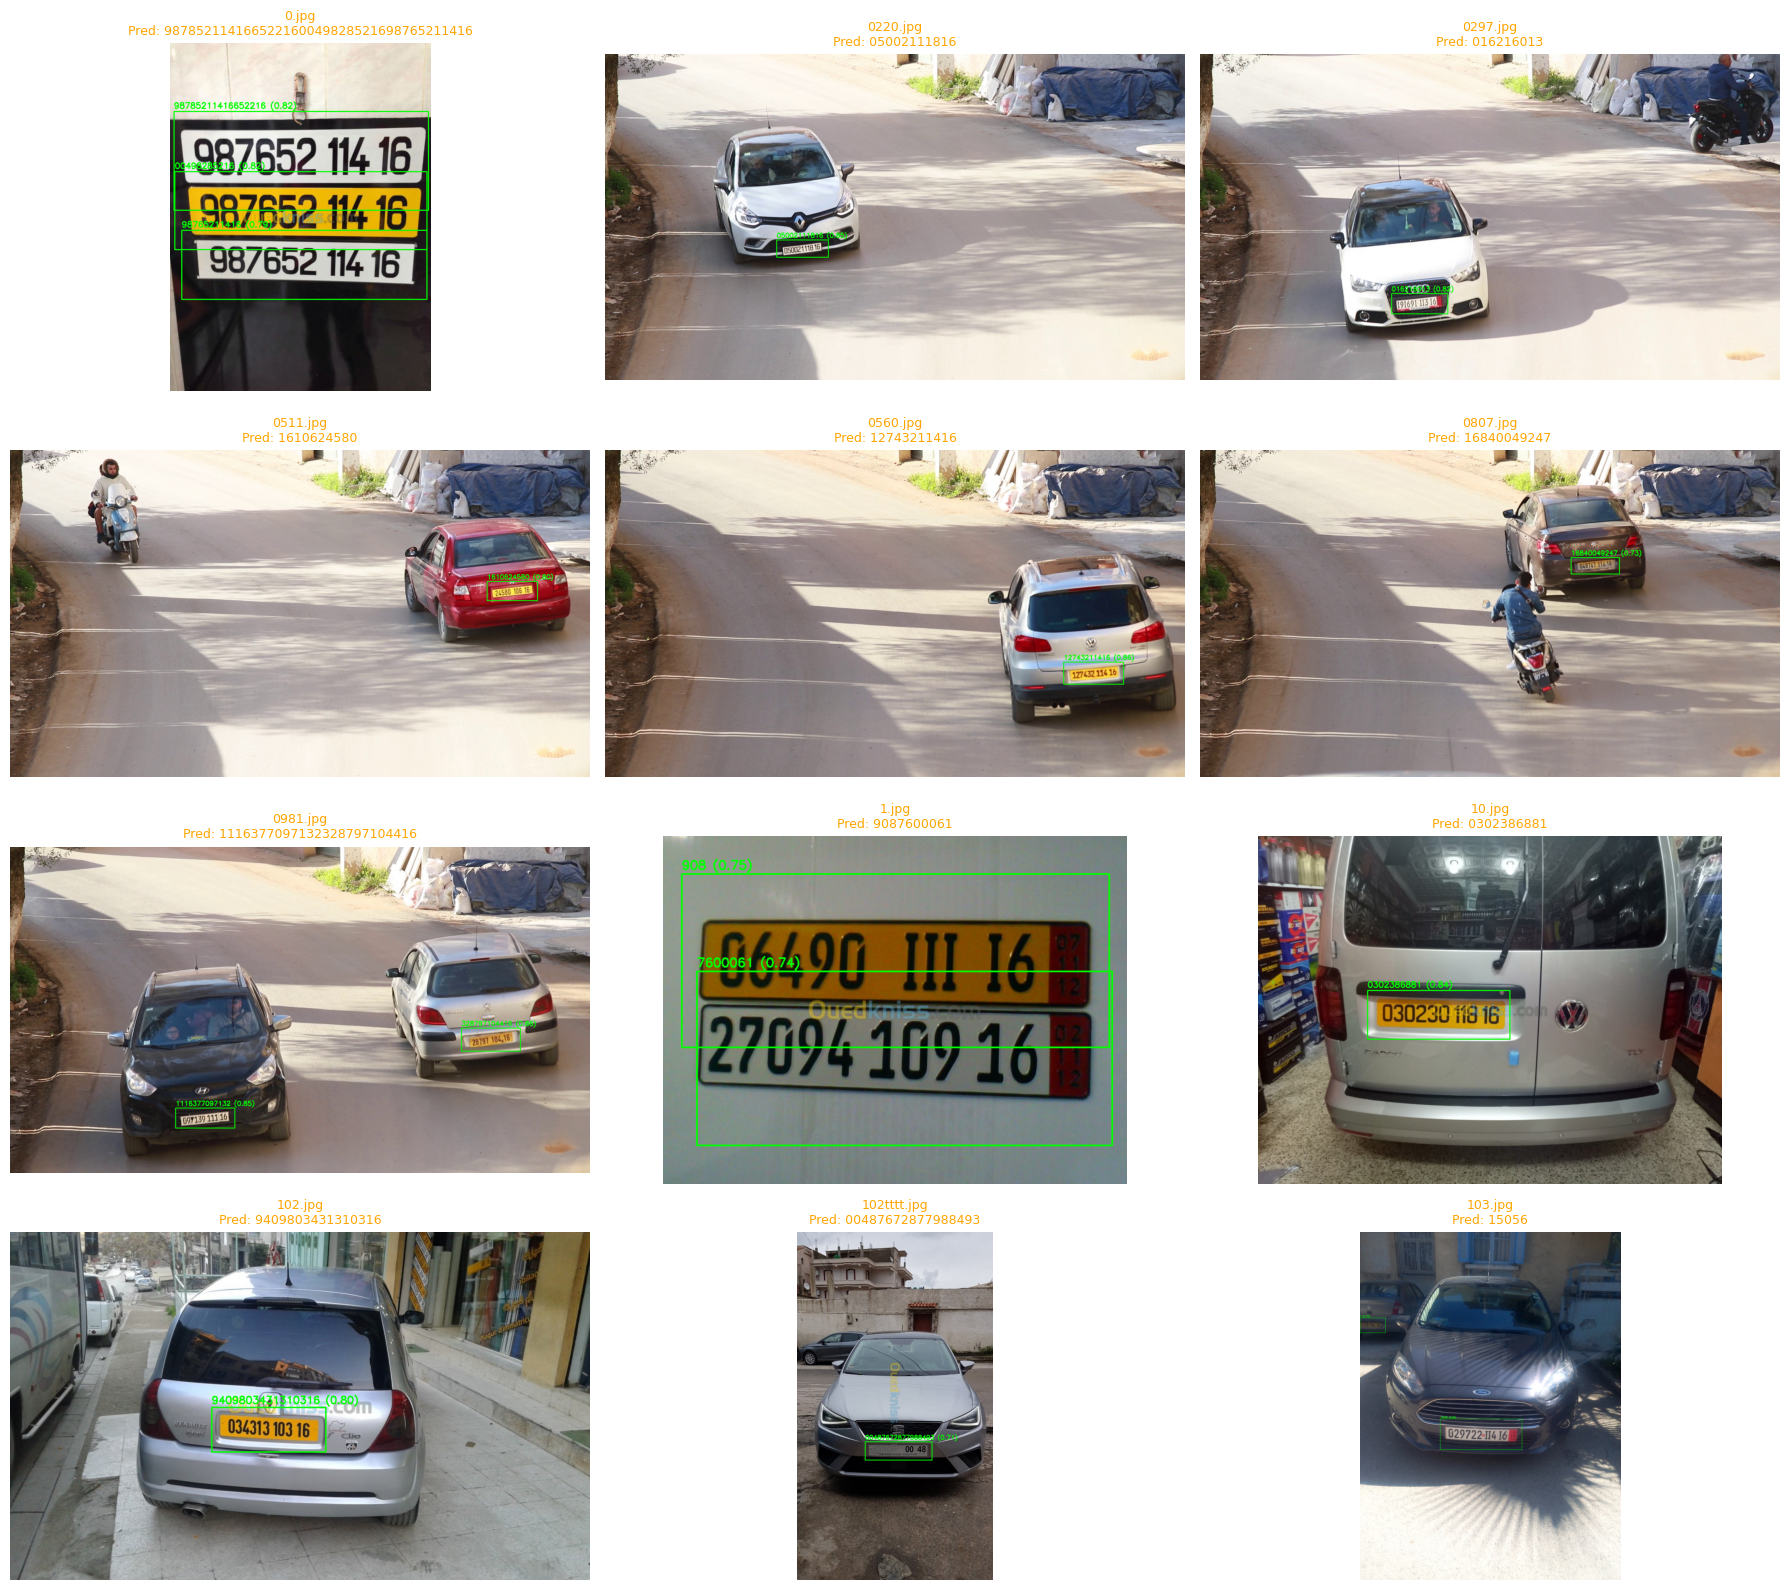

Saved → predictions_overview.png


: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

n = min(MAX_DISPLAY, len(results))
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten() if rows > 1 or cols > 1 else [axes]

for ax, res in zip(axes[:n], results[:n]):
    rgb = cv2.cvtColor(res.annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    color = 'green' if res.prediction == res.ground_truth and res.ground_truth else \
            'red'   if res.ground_truth else 'orange'
    title = f'{res.image_name}\nPred: {res.prediction or "(empty)"}'
    if res.ground_truth:
        title += f'  GT: {res.ground_truth}'
    ax.set_title(title, color=color, fontsize=9)
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → predictions_overview.png')

## 7. Metrics (only runs if labels are provided)

In [ ]:
import jiwer
import difflib

def calc_cer(gt, pred):
    gt   = ''.join(c for c in gt   if c.isdigit())
    pred = ''.join(c for c in pred if c.isdigit())
    if not gt: return 0.0 if not pred else 1.0
    if not pred: return 1.0
    try:
        return jiwer.cer(gt, pred)
    except Exception:
        return 1.0

def calc_digit_acc(gt, pred):
    gt   = ''.join(c for c in gt   if c.isdigit())
    pred = ''.join(c for c in pred if c.isdigit())
    if not gt: return 1.0 if not pred else 0.0
    if not pred: return 0.0
    return difflib.SequenceMatcher(None, gt, pred).ratio()

def calc_seq_acc(gt, pred):
    gt   = ''.join(c for c in gt   if c.isdigit())
    pred = ''.join(c for c in pred if c.isdigit())
    return 1.0 if gt == pred else 0.0

# Filter samples that have ground truth
labeled = [r for r in results if r.ground_truth]

if not labeled:
    print('No ground truth available — skipping metrics.')
    print('To enable metrics, set LABELS_FILE to a CSV with columns: image_name, label')
else:
    cers   = [calc_cer(r.ground_truth, r.prediction)       for r in labeled]
    daccs  = [calc_digit_acc(r.ground_truth, r.prediction) for r in labeled]
    saccs  = [calc_seq_acc(r.ground_truth, r.prediction)   for r in labeled]
    lats   = [r.latency_ms for r in results]

    print('=' * 52)
    print(f'  Evaluated samples    : {len(labeled)} / {len(results)}')
    print(f'  CER  (↓ better)      : {np.mean(cers):.3f}  ± {np.std(cers):.3f}')
    print(f'  Digit Accuracy  (↑)  : {np.mean(daccs):.3f}  ± {np.std(daccs):.3f}')
    print(f'  Sequence Accuracy(↑) : {np.mean(saccs):.3f}')
    print(f'  Avg Latency          : {np.mean(lats):.1f} ms')
    print(f'  Avg FPS              : {1000/np.mean(lats):.1f}')
    print('=' * 52)

    # Per-sample table
    rows_data = []
    for r, cer, da, sa in zip(labeled, cers, daccs, saccs):
        rows_data.append({
            'image':          r.image_name,
            'ground_truth':   r.ground_truth,
            'prediction':     r.prediction,
            'CER':            round(cer, 3),
            'Digit_Accuracy': round(da,  3),
            'Seq_Accuracy':   int(sa),
            'Latency_ms':     round(r.latency_ms, 1),
            'num_boxes':      r.num_boxes,
        })
    df = pd.DataFrame(rows_data)
    df.to_csv('metrics_per_sample.csv', index=False)
    print('\nPer-sample results saved → metrics_per_sample.csv')
    display(df.head(20))

## 8. Error analysis — worst predictions

In [ ]:
if not labeled:
    print('No labels — skipping error analysis.')
else:
    worst = sorted(zip(labeled, cers), key=lambda x: -x[1])[:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, (res, cer) in zip(axes, worst):
        rgb = cv2.cvtColor(res.annotated, cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        ax.set_title(
            f'{res.image_name}\nGT: {res.ground_truth}  PRED: {res.prediction or "(empty)"}\nCER: {cer:.3f}',
            color='red', fontsize=9
        )
        ax.axis('off')

    for ax in axes[len(worst):]:
        ax.axis('off')

    plt.suptitle('Worst Predictions (highest CER)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('worst_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved → worst_predictions.png')

## 9. Confidence threshold sweep — find the best CONF value

In [ ]:
# Test a few conf thresholds on the first 20 images and plot Digit Accuracy
sweep_images = image_paths[:20]
thresholds   = [0.10, 0.20, 0.25, 0.35, 0.50, 0.65, 0.80]
sweep_results = {}

for conf in thresholds:
    accs = []
    for img_path in sweep_images:
        image = cv2.imread(str(img_path))
        if image is None: continue
        h, w = image.shape[:2]
        yolo_res = model(image, conf=conf, iou=IOU_THRESHOLD, verbose=False)
        boxes = []
        if yolo_res and yolo_res[0].boxes is not None:
            for box in yolo_res[0].boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0].cpu().numpy())
                boxes.append((x1,y1,x2,y2))
        boxes = sorted(boxes, key=lambda b: b[0])
        if not boxes:
            boxes = [(0,0,w,h)]
        pred = ''.join(recognize_crop(image[y1:y2, x1:x2])[0] for x1,y1,x2,y2 in boxes)
        gt   = label_dict.get(img_path.name, label_dict.get(img_path.stem, ''))
        if gt:
            accs.append(calc_digit_acc(gt, pred))
    sweep_results[conf] = np.mean(accs) if accs else float('nan')
    print(f'  conf={conf:.2f}  Digit Accuracy={sweep_results[conf]:.3f}')

best_conf = max(sweep_results, key=lambda k: sweep_results[k] if not np.isnan(sweep_results[k]) else -1)
print(f'\nBest confidence threshold: {best_conf}  (DA={sweep_results[best_conf]:.3f})')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sweep_results.keys()), list(sweep_results.values()), 'o-', color='steelblue', linewidth=2)
ax.axvline(best_conf, color='red', linestyle='--', label=f'Best: {best_conf}')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Digit Accuracy')
ax.set_title('Conf Threshold vs Digit Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('conf_sweep.png', dpi=120)
plt.show()

## 10. Add `best.pt` as a registered pipeline in your benchmark system

Once you're happy with the model, add these blocks to **`pipelines/__init__.py`**:

In [ ]:
code = '''
# ── Add to PIPELINE_SPECS list in pipelines/__init__.py ───────────────────

PipelineSpec(
    pipeline_id="plate_best_easyocr",
    display_name="Plate YOLOv8n + EasyOCR (best.pt)",
    category="Detection + OCR",
    description="Custom car-plate YOLOv8n detector (best.pt) with EasyOCR recognition.",
    builder=_create_yolo_pipeline("best.pt", EasyOCRRecognizer, "EasyOCR"),
),
PipelineSpec(
    pipeline_id="plate_best_tesseract",
    display_name="Plate YOLOv8n + Tesseract (best.pt)",
    category="Detection + OCR",
    description="Custom car-plate YOLOv8n detector (best.pt) with Tesseract recognition.",
    builder=_create_yolo_pipeline("best.pt", TesseractRecognizer, "Tesseract"),
),
'''
print(code)

Copy the output above and paste it into your `PIPELINE_SPECS` list.  
After that, `python main.py --list-pipelines` will show your new model, and you can run:
```powershell
python main.py --pipeline plate_best_easyocr --data-source images --image-dir .\test_images
```
or select it from the Streamlit dropdown.